# Imports and Load Data


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


## Explore Data
- Claims data, each row shows a members claim, service provided, their providers id, claim status and the reviewer.

In [5]:
df = pd.read_csv('/content/AI-Eng-Data-Challenge.csv')
df

,claim_id,member_name,service,submission_date,provider_id,claimstatus,auto_approved_claim,clinical_reviewer,member_id,reason
0,001d0f43-33a2-4add-b8a8-2b32b73ef318,Sophie,Vaccination,2/24/2024 14:26,1008,Approved,False,NaN,MBR-1953,Full coverage approved: Routine annual immuniz...
1,003031d6-cf95-4c0c-b0f2-06c89dff726f,Harper,Lab Test,11/26/2023 14:26,1006,Approved,False,NaN,MBR-8260,Approved: Laboratory panel (3 units) is medica...
2,003fae46-1e76-4aba-8670-95d9dabf1848,Gunther,Vaccination,7/17/2024 14:26,1002,Approved,False,NaN,MBR-1854,Approved: Multi-dose viral series (4 units) fu...
3,004389e2-75b9-484d-ab9b-cd9b00e8af4f,Thomas,X-ray,4/25/2024 14:26,1003,Denied,False,NaN,MBR-7814,Denied: Duplicate service submission; initial ...
4,004e13f1-d8ed-4e32-8d3d-886764f7835b,Roxy,Dental Cleaning,9/25/2023 14:26,1019,Denied,False,NaN,MBR-4027,Denied: Frequency limit exceeded; last dental ...
...,...,...,...,...,...,...,...,...,...,...
1017,5640012e-ce13-401f-b77a-832a9afc9c3d,Cooper,X-ray,1/8/2024 14:26,1014,Denied,False,NaN,MBR-7513,Policy requirements not met.
1018,564eaadf-53a5-4fac-8cec-38a71ff32198,Missy,Vaccination,3/24/2024 14:26,1016,Approved,False,NaN,MBR-5837,Meets all policy requirements.
1019,565ae44c-f90f-421f-8909-4e800e4f1b8a,Nike,Check-up,1/2/2024 14:26,1007,Approved,False,NaN,MBR-1197,Meets all policy requirements.
1020,56697a32-ae59-4c0b-b3f6-47d330bd8e0a,Lizzy,Lab Test,4/4/2024 14:26,1003,Approved,False,NaN,MBR-7824,Meets all policy requirements.


## Initial Questions:

#### Cleaning
- [x] Are there Missing values?
- [x] Duplicate claims?


#### Analytics & Understanding:
- [x] What is the total number of claims Approved / Denied / Pending?
- [x] Overall distribution (amount of claims) of services, providers, and members (high risk members?
- [x] Trend of claims over time?
- [x] How many claims are auto approved and how many are not?

#### Metrics & NLP
- [x] What is the approval rate and denial rate for each of the following categories; Service, Member_id, Provider_id.
- 5 most common phrases among approved and denied?



### Additional Notes & Questions
- With Age we could look at number of claims in different age brackets.
- Approved claims, Indicates operational success and customer fulfillment
- Rejected claims, high rejections may indicate policy mismatches, fraud, or documentation issues. May provide insights into what needs to be changed, may damage customer satisfaction.
- Pending claims, operational bottlenecks, hanging resolutions. Points to where tuning and automation may be helpful.

- Important to identify high risk members for future costs.
- Providers with high denial rates could indicate poor documentation or potentially fraud.
- Members with high denial rate may point to plan mismatch due to policy issues.
- Reviewers can show stricter decision making or processing inconsistencies.



In [6]:
#lets check the missing values and for duplicate records.
print(df.shape)

#Convert date to usable object
df['submission_date'] = pd.to_datetime(df['submission_date'])


missing = df.isna().sum()
full_dupes = df.duplicated().sum()
id_dupes = df['claim_id'].duplicated().sum()

print("Missing Values:\n", missing)
print("Full Row Duplicate Values: ", full_dupes)
print("ID Duplicate Values: ", id_dupes)
#Data looks very clean, missing reviewers does not cause an issue here.

(1022, 10)
Missing Values:
 claim_id                 0
member_name              0
service                  0
submission_date          0
provider_id              0
claimstatus              0
auto_approved_claim      0
clinical_reviewer      715
member_id                0
reason                   0
dtype: int64
Full Row Duplicate Values:  0
ID Duplicate Values:  0


In [7]:

#get an understanding of claim counts and stats
totals = df['claimstatus'].value_counts().reset_index()
totals['percent_count'] = 100*(totals['count']/totals['count'].sum()).round(3)


#distribution of types of service
service_dist = df.service.value_counts().reset_index()
service_dist['percent_count'] = 100*(service_dist['count']/service_dist['count'].sum()).round(3)

#approval, denial and pending rate
service_stat = df.groupby('service')['claimstatus'].value_counts().unstack()
service_stat = service_stat.reset_index()

service_summary = service_dist.join(service_stat.set_index('service'), on='service')
service_summary = service_summary.fillna(0)


display(totals)
display(service_summary)

,claimstatus,count,percent_count
0,Approved,705,69.0
1,Denied,275,26.9
2,Pending,42,4.1


,service,count,percent_count,Approved,Denied,Pending
0,Check-up,295,28.9,293.0,2.0,0.0
1,X-ray,198,19.4,72.0,115.0,11.0
2,Vaccination,168,16.4,125.0,34.0,9.0
3,Dental Cleaning,158,15.5,76.0,73.0,9.0
4,Lab Test,107,10.5,83.0,14.0,10.0
5,Surgery,96,9.4,56.0,37.0,3.0


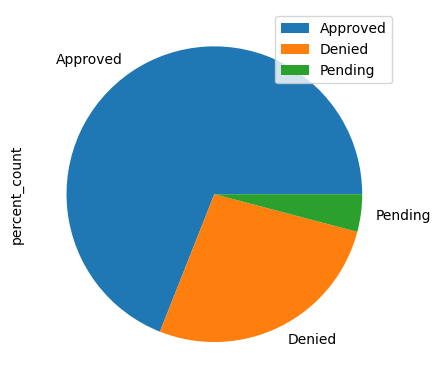

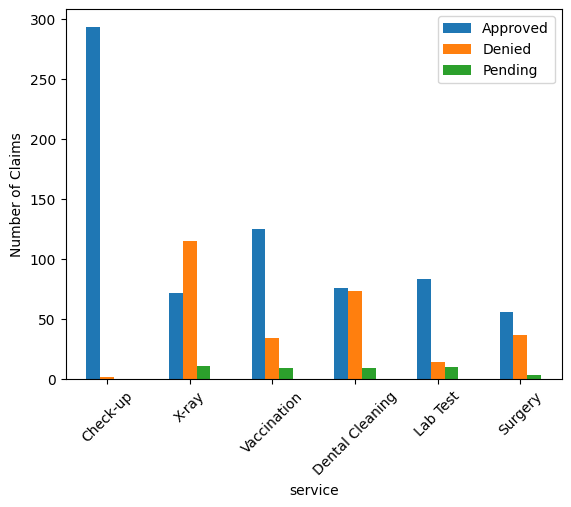

In [8]:
#Pie chart for total approval, denial, and pending
totals.set_index('claimstatus').plot.pie(y='percent_count')
#services bar chart 3 classes for each category. approved, denied, pending. Normalize counts above for %.
ax = service_summary.plot(x="service", y=["Approved", "Denied", "Pending"], kind="bar", rot=45)
plt.ylabel("Number of Claims")
plt.show()

In [9]:
#Why are there 2 checkups denied?
df[(df['claimstatus']=='Denied') & (df['service']=='Check-up')]

,claim_id,member_name,service,submission_date,provider_id,claimstatus,auto_approved_claim,clinical_reviewer,member_id,reason
151,0d25589f-7e1e-42ab-902d-785ce2114128,Alexander,Check-up,2023-11-29 14:26:00,1001,Denied,False,Leah Duncan,MBR-5793,Policy requirements not met.
384,1f2d3fe2-6767-4159-99d7-5f88c8beeb3b,Stella,Check-up,2024-07-08 14:26:00,1007,Denied,False,NaN,MBR-7388,Denied: Claim for Check-up for Member ID MBR-7...


In [10]:
#why are X-rays often denied?
df[(df['claimstatus']=='Denied') & (df['service']=='X-ray')]

,claim_id,member_name,service,submission_date,provider_id,claimstatus,auto_approved_claim,clinical_reviewer,member_id,reason
3,004389e2-75b9-484d-ab9b-cd9b00e8af4f,Thomas,X-ray,2024-04-25 14:26:00,1003,Denied,False,NaN,MBR-7814,Denied: Duplicate service submission; initial ...
5,0063b8f5-a902-4999-badd-90a94957bb8a,Taz,X-ray,2024-05-27 14:26:00,1008,Denied,False,NaN,MBR-9503,Denied: Imaging (3 units) lacks supporting cli...
6,006b52b2-c6cf-4e6b-b8bf-abb99a06248f,Anthony,X-ray,2023-12-22 14:26:00,1006,Denied,False,Ellen Atkinson,MBR-7730,Denied: Service (2 units) provided by an out-o...
20,01437dab-c431-4c28-9fab-ca2535e3b2c8,Harper,X-ray,2024-03-04 14:26:00,1000,Denied,False,NaN,MBR-8260,Denied: Policy excludes coverage for post-trea...
24,019e0f7f-4c3a-4ef5-b40a-f57590221ac1,Theo,X-ray,2024-04-16 14:26:00,1000,Denied,False,Bruce Campbell,MBR-4033,Denied: Radiographic study (2 units) is non-di...
...,...,...,...,...,...,...,...,...,...,...
982,53ec86dd-d634-4b5c-8d26-5e8ed09afb12,Bear,X-ray,2023-11-03 14:26:00,1017,Denied,False,NaN,MBR-5946,Denied: Unique reason with specific policy exc...
992,54c23007-d2d7-413f-bb52-70845120c05c,Oliver,X-ray,2024-05-04 14:26:00,1018,Denied,False,NaN,MBR-1326,Denied: Unique reason with specific policy exc...
994,54e87ae7-0490-481c-a32d-407f8d4834a4,Silvia,X-ray,2023-11-07 14:26:00,1001,Denied,False,NaN,MBR-8832,Denied: Unique reason with specific policy exc...
1012,5603b4a4-3f61-4116-930b-4c3f5112caca,Sasha,X-ray,2023-12-12 14:26:00,1013,Denied,False,Lincoln Sampson,MBR-1415,Denied: Unique reason with specific policy exc...


In [11]:
#top 5 most common providers
provider_dist = df.provider_id.value_counts().reset_index()
provider_stat = df.groupby('provider_id')['claimstatus'].value_counts(normalize=True).unstack().reset_index()
provider_summary = provider_dist.join(provider_stat.set_index('provider_id'), on='provider_id')
provider_summary = provider_summary.fillna(0)
display(provider_summary.head())

#top 5 members with highest claim count
member_dist = df.member_id.value_counts().reset_index()
member_stat = df.groupby('member_id')['claimstatus'].value_counts().unstack().reset_index()
member_summary = member_dist.join(member_stat.set_index('member_id'), on='member_id')
member_summary = member_summary.rename(columns={"count":"Claims_Count"})

,provider_id,count,Approved,Denied,Pending
0,1008,56,0.660714,0.303571,0.035714
1,1006,56,0.821429,0.160714,0.017857
2,1005,56,0.732143,0.232143,0.035714
3,1013,56,0.660714,0.321429,0.017857
4,1018,54,0.648148,0.296296,0.055556


In [12]:
#What services do each member use most
member_service_count = df.groupby(['member_id'])['service'].value_counts().unstack().reset_index()
member_summary = member_summary.join(member_service_count.set_index('member_id'), on='member_id')
round_this = ['Approved', 'Denied', 'Pending']
for col in round_this:
  member_summary[col] = member_summary[col].round(3)
member_summary = member_summary.fillna(0)
member_summary

,member_id,Claims_Count,Approved,Denied,Pending,Check-up,Dental Cleaning,Lab Test,Surgery,Vaccination,X-ray
0,MBR-2366,16,12.0,4.0,0.0,7.0,2.0,1.0,2.0,2.0,2.0
1,MBR-3458,15,10.0,5.0,0.0,5.0,2.0,0.0,2.0,1.0,5.0
2,MBR-5992,13,8.0,5.0,0.0,4.0,3.0,1.0,1.0,2.0,2.0
3,MBR-4079,13,13.0,0.0,0.0,6.0,4.0,0.0,0.0,0.0,3.0
4,MBR-4027,12,6.0,6.0,0.0,2.0,4.0,0.0,0.0,4.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...
152,MBR-7252,3,3.0,0.0,0.0,2.0,0.0,0.0,0.0,1.0,0.0
153,MBR-8260,2,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
154,MBR-2756,2,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
155,MBR-7239,2,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [13]:
#sanity check
member_summary['Claims_Count'].sum()

np.int64(1022)

2023-08-20 14:26:00 2024-08-19 14:26:00


<Axes: title={'center': 'Claims Over Time'}, xlabel='year_month'>

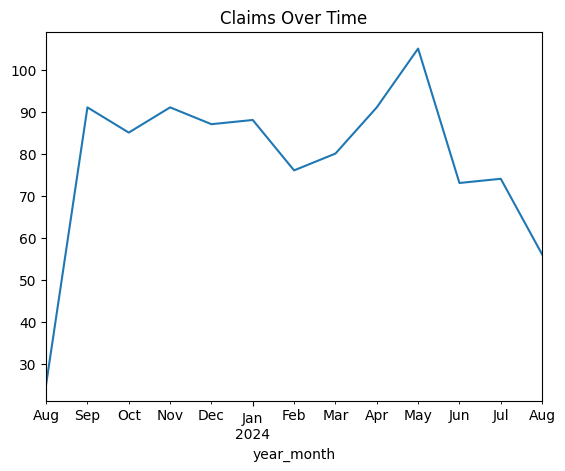

In [14]:
#looking through aug-2023 to aug-2024
print(df.submission_date.min(), df.submission_date.max())
df['year_month'] = df.submission_date.dt.to_period('M')
monthly_counts = (df.groupby('year_month').size())
monthly_counts.plot(title='Claims Over Time', x='year_month', y='claims count', kind='line')

## 1. Observations

- We have a clean claims dataset with no missing values or duplicate records. (Aside from the reviewer column)
- We explored the total Approved, Denied, and Pending claims, we can see a distribution of ~ 69% approved, 27% denied, and 4% pending.
- Looking into each service we find where the claims fall under each category, we can see that nearly all the Check-Up services were approved with 2 policy related denials. X-Ray, dental_cleaning and surgery services have the highest denial rates, this could be due to policy issues or non-essential services and could be candidates for additional research.
- X-ray denials seem to be largely due to policy requirements not being met. This may indicate a need for change in policy to improve customer satisfaction.
- Additionally with the member summary table we can see which members have high denial rates, high number of claims, and their corresponding services. This indicates which members are high risk, potential plan mismatch with high denial rates, and the common services each member undergoes.


## Claims Status & Auto Approved Claims
- To compare and identify the relationship between 'claimstatus' and 'auto_approved_claim', I determined the distribution of auto approved claims and the number of auto approved claims for each service.
- Auto approved claims are primarily standard coverage and **preventive care services** suggesting the model is designed to handle low-risk standard cases.
- The manually decided claims are generally more ambiguous and more complex scenarios.
- After comparing the approval rate of manual and auto approved claims, the model accurately handles the simple and more standard claims they only occount for 191 of the total 1022 claims. This is ~20% of the total claims meaning majority of the claims still require manual review.

In [38]:
# lets review the auto approved claims and determine the effectiveness.
auto_claims_count = df.groupby('auto_approved_claim').size().reset_index(name='claims_count')
display(auto_claims_count)


#what types of service does the auto review approve mainly
auto_service_count = df[df['auto_approved_claim']==True].groupby(['service']).size().reset_index(name='auto_approved_count')
manual_service_count = df[df['auto_approved_claim']==False].groupby(['service']).size().reset_index(name='manually_decided')
auto_claim_summary = auto_service_count.join(manual_service_count.set_index('service'), on='service')
auto_claim_summary

,auto_approved_claim,claims_count
0,False,831
1,True,191


,service,auto_approved_count,manually_decided
0,Check-up,92,203
1,Dental Cleaning,6,152
2,Lab Test,27,80
3,Surgery,2,94
4,Vaccination,37,131
5,X-ray,27,171


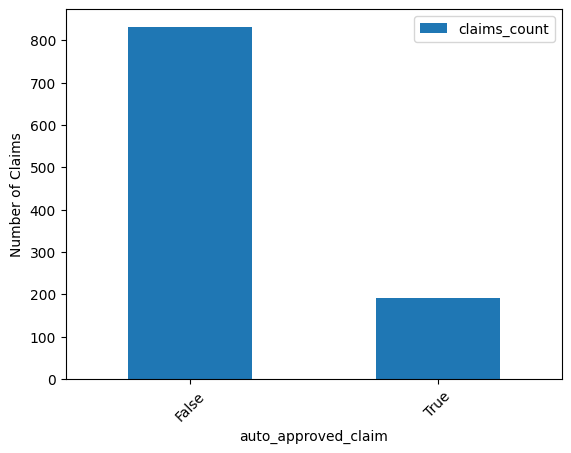

In [27]:
ax = auto_claims_count.plot(x="auto_approved_claim", y='claims_count', kind="bar", rot=45)
plt.ylabel("Number of Claims")
plt.show()

In [16]:
auto_approved = df[df['auto_approved_claim']==True]
display(auto_approved)

,claim_id,member_name,service,submission_date,provider_id,claimstatus,auto_approved_claim,clinical_reviewer,member_id,reason,year_month
9,00782d5e-0960-400c-9fae-1c4cb16bd091,Jake,Lab Test,2024-06-12 14:26:00,1020,Approved,True,NaN,MBR-9578,Approved: High-volume metabolic panel (3 units...,2024-06
10,007e91a5-6260-4d69-bd60-1e3e0d8e9677,Alice,Lab Test,2023-12-23 14:26:00,1008,Approved,True,NaN,MBR-2923,Approved: Single therapeutic drug monitoring t...,2023-12
18,013728bb-cd98-421c-9512-71ee9e3c412c,Prince,Check-up,2023-10-12 14:26:00,1008,Approved,True,NaN,MBR-1525,Approved: Zero-balance routine office visit (1...,2023-10
30,02159f83-98f9-4d10-abc2-af20a5f62766,Apollo,Check-up,2024-02-20 14:26:00,1017,Approved,True,NaN,MBR-2855,Meets all policy requirements.,2024-02
31,0215ae2f-a021-4c4d-83ff-5bf1cddd495c,Kobe,Check-up,2023-09-12 14:26:00,1008,Approved,True,Kaylee Wiley,MBR-8939,Meets all policy requirements.,2023-09
...,...,...,...,...,...,...,...,...,...,...,...
989,5455ac77-1632-4081-a856-8c917b99feea,Nina,Check-up,2024-08-04 14:26:00,1012,Approved,True,NaN,MBR-5378,"Approved: Unique reason with full coverage, pr...",2024-08
1002,5536e439-0ba9-44cb-87d3-cd35533b35aa,Blue,X-ray,2024-05-03 14:26:00,1013,Approved,True,NaN,MBR-4079,"Approved: Unique reason with full coverage, pr...",2024-05
1004,55479c85-5ce1-4205-a29c-7dbf8457cca3,Benny,Vaccination,2024-08-10 14:26:00,1018,Approved,True,Ty Joseph,MBR-3955,"Approved: Unique reason with full coverage, pr...",2024-08
1007,559dcf22-7caa-44d5-aab6-1c4123e51d4f,Gio,Lab Test,2024-04-30 14:26:00,1020,Approved,True,NaN,MBR-2366,"Approved: Unique reason with full coverage, pr...",2024-04


In [17]:
manual = df[df['auto_approved_claim']==False]
display(manual)

,claim_id,member_name,service,submission_date,provider_id,claimstatus,auto_approved_claim,clinical_reviewer,member_id,reason,year_month
0,001d0f43-33a2-4add-b8a8-2b32b73ef318,Sophie,Vaccination,2024-02-24 14:26:00,1008,Approved,False,NaN,MBR-1953,Full coverage approved: Routine annual immuniz...,2024-02
1,003031d6-cf95-4c0c-b0f2-06c89dff726f,Harper,Lab Test,2023-11-26 14:26:00,1006,Approved,False,NaN,MBR-8260,Approved: Laboratory panel (3 units) is medica...,2023-11
2,003fae46-1e76-4aba-8670-95d9dabf1848,Gunther,Vaccination,2024-07-17 14:26:00,1002,Approved,False,NaN,MBR-1854,Approved: Multi-dose viral series (4 units) fu...,2024-07
3,004389e2-75b9-484d-ab9b-cd9b00e8af4f,Thomas,X-ray,2024-04-25 14:26:00,1003,Denied,False,NaN,MBR-7814,Denied: Duplicate service submission; initial ...,2024-04
4,004e13f1-d8ed-4e32-8d3d-886764f7835b,Roxy,Dental Cleaning,2023-09-25 14:26:00,1019,Denied,False,NaN,MBR-4027,Denied: Frequency limit exceeded; last dental ...,2023-09
...,...,...,...,...,...,...,...,...,...,...,...
1017,5640012e-ce13-401f-b77a-832a9afc9c3d,Cooper,X-ray,2024-01-08 14:26:00,1014,Denied,False,NaN,MBR-7513,Policy requirements not met.,2024-01
1018,564eaadf-53a5-4fac-8cec-38a71ff32198,Missy,Vaccination,2024-03-24 14:26:00,1016,Approved,False,NaN,MBR-5837,Meets all policy requirements.,2024-03
1019,565ae44c-f90f-421f-8909-4e800e4f1b8a,Nike,Check-up,2024-01-02 14:26:00,1007,Approved,False,NaN,MBR-1197,Meets all policy requirements.,2024-01
1020,56697a32-ae59-4c0b-b3f6-47d330bd8e0a,Lizzy,Lab Test,2024-04-04 14:26:00,1003,Approved,False,NaN,MBR-7824,Meets all policy requirements.,2024-04


In [25]:
#Lets evaluate the auto approved claims
auto_claims_status = pd.crosstab(df['auto_approved_claim'], df['claimstatus'], normalize='index').reset_index()
auto_claims_status

claimstatus,auto_approved_claim,Approved,Denied,Pending
0,False,0.618532,0.330927,0.050542
1,True,1.000000,0.000000,0.000000


## Reasoning

In [70]:
#Lets check the reasoning behind approvals and denials
df['reason'] = [reason.lower().strip() for reason in df['reason']]
reason_df = df.groupby(['claimstatus', 'reason']).size().reset_index(name='count').sort_values(by='count', ascending=False)

In [68]:
display(reason_df[reason_df['claimstatus']=='Approved'].head())

,claimstatus,reason,count
400,Approved,meets all policy requirements.,236
336,Approved,"approved: unique reason with full coverage, pr...",46
193,Approved,approved: routine service covered under standa...,24
262,Approved,approved: standard coverage for check-up confi...,2
386,Approved,approved: x-ray for mbr mbr-6270 meets standar...,1


In [69]:
display(reason_df[reason_df['claimstatus']=='Denied'].head())

,claimstatus,reason,count
563,Denied,policy requirements not met.,73
518,Denied,denied: unique reason with specific policy exc...,26
458,Denied,denied: policy exclusion applies; service is c...,16
418,Denied,denied: claim for x-ray for member id mbr-3089...,1
419,Denied,denied: claim for x-ray for member id mbr-3467...,1


In [83]:
from sklearn.feature_extraction.text import CountVectorizer
import nltk
import re
from collections import Counter

nlp_df = df.copy()

vectorizer = CountVectorizer(analyzer='word', ngram_range=(3, 3))
X = vectorizer.fit_transform(nlp_df[nlp_df['claimstatus']=='Approved']['reason'])
counts = X.sum(axis=0)
ngrams = [(word, counts[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
sorted(ngrams, key=lambda x: -x[1])[:10]

[('all policy requirements', np.int64(292)),
 ('policy information standard', np.int64(252)),
 ('meets all policy', np.int64(236)),
 ('standard coverage provider', np.int64(235)),
 ('information standard coverage', np.int64(227)),
 ('standard coverage id', np.int64(227)),
 ('is in network', np.int64(222)),
 ('for mbr mbr', np.int64(195)),
 ('in network and', np.int64(195)),
 ('is compliant policy', np.int64(195))]

In [84]:
vectorizer = CountVectorizer(analyzer='word', ngram_range=(3, 3))
X = vectorizer.fit_transform(nlp_df[nlp_df['claimstatus']=='Denied']['reason'])
counts = X.sum(axis=0)
ngrams = [(word, counts[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
sorted(ngrams, key=lambda x: -x[1])[:10]

[('documentation is insufficient', np.int64(80)),
 ('for mbr mbr', np.int64(75)),
 ('failed policy due', np.int64(75)),
 ('policy due to', np.int64(75)),
 ('due to specific', np.int64(75)),
 ('to specific denial', np.int64(75)),
 ('specific denial reason', np.int64(75)),
 ('denial reason from', np.int64(75)),
 ('reason from 10', np.int64(75)),
 ('from 10 policy', np.int64(75))]

In [73]:
nlp_df

,claim_id,member_name,service,submission_date,provider_id,claimstatus,auto_approved_claim,clinical_reviewer,member_id,reason,year_month
0,001d0f43-33a2-4add-b8a8-2b32b73ef318,Sophie,Vaccination,2024-02-24 14:26:00,1008,Approved,False,NaN,MBR-1953,full coverage approved: routine annual immuniz...,2024-02
1,003031d6-cf95-4c0c-b0f2-06c89dff726f,Harper,Lab Test,2023-11-26 14:26:00,1006,Approved,False,NaN,MBR-8260,approved: laboratory panel (3 units) is medica...,2023-11
2,003fae46-1e76-4aba-8670-95d9dabf1848,Gunther,Vaccination,2024-07-17 14:26:00,1002,Approved,False,NaN,MBR-1854,approved: multi-dose viral series (4 units) fu...,2024-07
3,004389e2-75b9-484d-ab9b-cd9b00e8af4f,Thomas,X-ray,2024-04-25 14:26:00,1003,Denied,False,NaN,MBR-7814,denied: duplicate service submission; initial ...,2024-04
4,004e13f1-d8ed-4e32-8d3d-886764f7835b,Roxy,Dental Cleaning,2023-09-25 14:26:00,1019,Denied,False,NaN,MBR-4027,denied: frequency limit exceeded; last dental ...,2023-09
...,...,...,...,...,...,...,...,...,...,...,...
1017,5640012e-ce13-401f-b77a-832a9afc9c3d,Cooper,X-ray,2024-01-08 14:26:00,1014,Denied,False,NaN,MBR-7513,policy requirements not met.,2024-01
1018,564eaadf-53a5-4fac-8cec-38a71ff32198,Missy,Vaccination,2024-03-24 14:26:00,1016,Approved,False,NaN,MBR-5837,meets all policy requirements.,2024-03
1019,565ae44c-f90f-421f-8909-4e800e4f1b8a,Nike,Check-up,2024-01-02 14:26:00,1007,Approved,False,NaN,MBR-1197,meets all policy requirements.,2024-01
1020,56697a32-ae59-4c0b-b3f6-47d330bd8e0a,Lizzy,Lab Test,2024-04-04 14:26:00,1003,Approved,False,NaN,MBR-7824,meets all policy requirements.,2024-04


# Additional
- Reviewer
- claims over time
- etc.